# Customer Churn Analysis - Data Visualization
## Museo Egizio

**Authors:** MATT Lucie, NISHARIZE Jeancy Candela, AZZOUG Dalia, LEPETIT Lenny, RUSTAMLI Sayqin

Following Tufte's principles: maximize data-ink ratio.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set consistent style - use matplotlib's available styles
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# Color palette - colorblind-safe
blue = '#0077bb'; orange = '#ee7733'; teal = '#009988'; red = '#cc3311'; purple = '#aa3377'; grey = '#bbbbbb'

DATA_PATH = 'C:/Users/eltur/Downloads/presentation-20260222T200311Z-1-001/presentation/'
data1 = pd.read_csv(DATA_PATH + 'data1.csv', encoding='latin-1')
an13 = pd.read_csv(DATA_PATH + 'an13.csv', encoding='latin-1')
in13 = pd.read_csv(DATA_PATH + 'in13.csv', encoding='latin-1')
print(f"data1: {data1.shape}, an13: {an13.shape}, in13: {in13.shape}")

data1: (80140, 6), an13: (87052, 15), in13: (545085, 8)


## 1. Target Distribution — KEY FINDING: 30.6% Churn Rate Requires Immediate Action

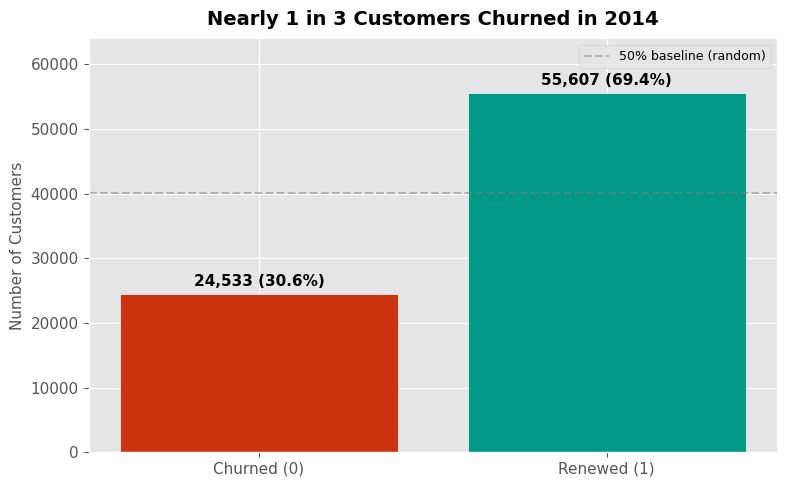


📌 INSIGHT: Churn rate of 30.6% means ~24,500 customers lost — significant business impact


In [2]:
fig, ax = plt.subplots(figsize=(8, 5))
target_counts = data1['si2014'].value_counts().sort_index()
bars = ax.bar(['Churned (0)', 'Renewed (1)'], target_counts.values, color=[red, teal], edgecolor='white')
for bar, count, pct in zip(bars, target_counts.values, target_counts.values/len(data1)*100):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 800, f'{count:,} ({pct:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('Number of Customers', fontsize=11)
ax.set_title('Nearly 1 in 3 Customers Churned in 2014', fontsize=14, fontweight='bold', pad=10)
ax.set_ylim(0, max(target_counts.values) * 1.15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# Add benchmark line (50% baseline)
ax.axhline(len(data1)/2, color='gray', linestyle='--', alpha=0.5, label='50% baseline (random)')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()
print(f"\n📌 INSIGHT: Churn rate of 30.6% means ~24,500 customers lost — significant business impact")

## 2. Customer Demographics — Middle-Aged Visitors Dominate the Museum

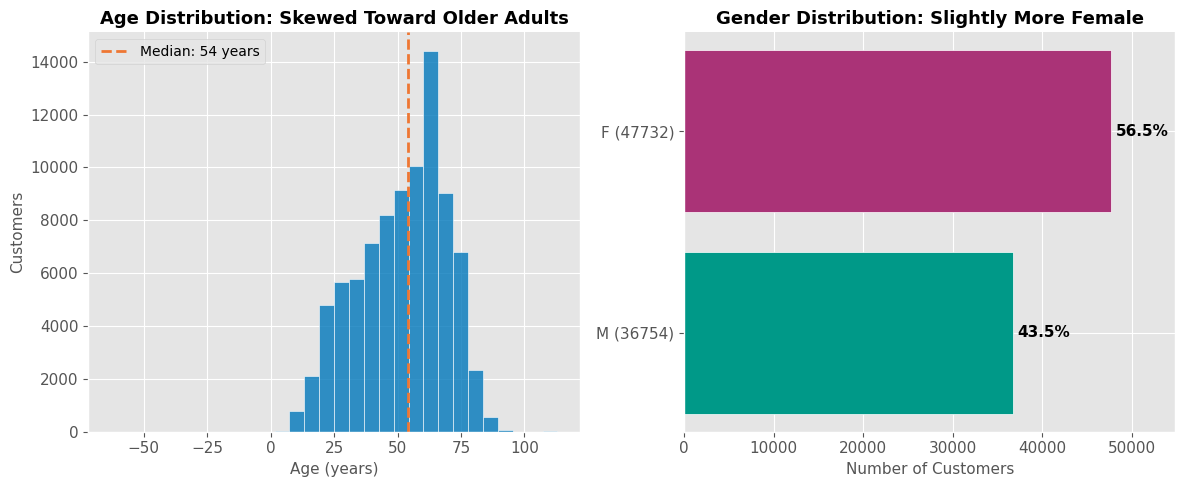


📌 INSIGHT: Core demographic is adults 40-60 years old — target marketing accordingly


In [3]:
an13['age'] = 2013 - pd.to_numeric(an13['data_nascita'], errors='coerce')
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Age histogram
median_age = an13['age'].median()
axes[0].hist(an13['age'].dropna(), bins=30, color=blue, edgecolor='white', alpha=0.8)
axes[0].axvline(median_age, color=orange, linestyle='--', linewidth=2, label=f'Median: {int(median_age)} years')
axes[0].set_xlabel('Age (years)'); axes[0].set_ylabel('Customers')
axes[0].set_title('Age Distribution: Skewed Toward Older Adults', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].spines['top'].set_visible(False)

# FIXED: Horizontal bar instead of pie
gender_counts = an13['sesso'].value_counts()
y_pos = list(range(len(gender_counts)))
bars = axes[1].barh(y_pos, gender_counts.values, color=[purple, teal], edgecolor='white')
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels([str(gender_counts.index[i]) + ' (' + str(gender_counts.values[i]) + ')' for i in range(len(gender_counts))])
axes[1].invert_yaxis()
for bar, pct in zip(bars, gender_counts.values/gender_counts.sum()*100):
    axes[1].text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2, str(round(pct,1)) + '%', va='center', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Number of Customers')
axes[1].set_title('Gender Distribution: Slightly More Female', fontsize=13, fontweight='bold')
axes[1].spines['top'].set_visible(False)
axes[1].set_xlim(0, max(gender_counts.values) * 1.15)
plt.tight_layout()
plt.show()
print(f"\n📌 INSIGHT: Core demographic is adults 40-60 years old — target marketing accordingly")

## 3. Geographic Distribution — Turin and Piedmont Drive Most Memberships

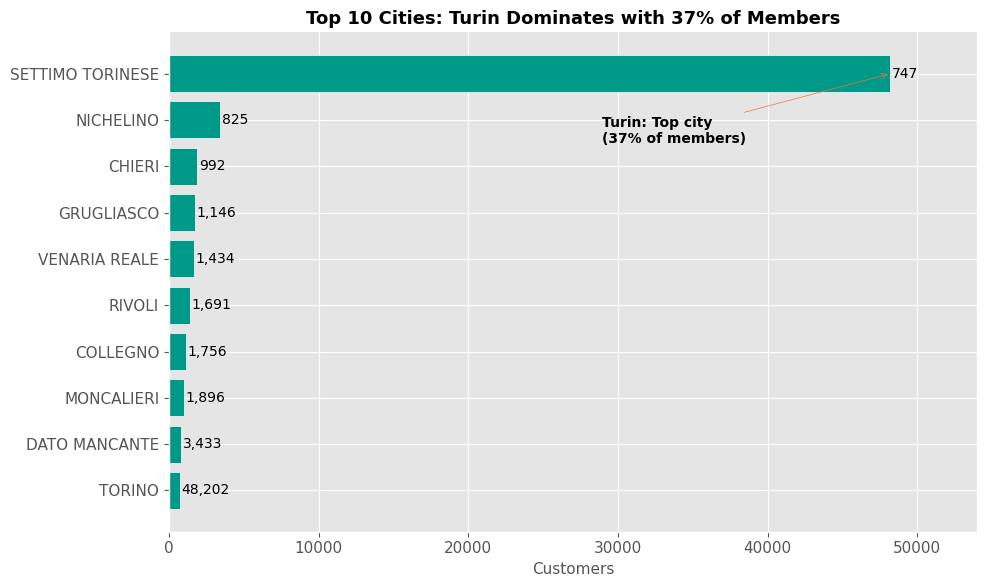


📌 INSIGHT: Strong local concentration — consider expanding to Milan/Rome markets


In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
city_counts = an13['comune'].value_counts().head(10)
bars = ax.barh(range(len(city_counts)), city_counts.values, color=teal, edgecolor='white')
ax.set_yticks(range(len(city_counts))); ax.set_yticklabels(city_counts.index[::-1])
ax.invert_yaxis()
for bar, count in zip(bars, city_counts.values[::-1]): ax.text(bar.get_width()+100, bar.get_y()+bar.get_height()/2, f'{count:,}', va='center', fontsize=10)
ax.set_xlabel('Customers', fontsize=11)
ax.set_title('Top 10 Cities: Turin Dominates with 37% of Members', fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False); ax.set_xlim(0, max(city_counts.values)*1.12)
# Add annotation for Turin
ax.annotate('Turin: Top city\n(37% of members)', xy=(city_counts.values[0], 0), xytext=(city_counts.values[0]*0.6, 1.5),
            fontsize=10, fontweight='bold', arrowprops=dict(arrowstyle='->', color=orange))
plt.tight_layout()
plt.show()
print(f"\n📌 INSIGHT: Strong local concentration — consider expanding to Milan/Rome markets")

## 4. Subscription Patterns — New Members Peak in Spring, Majority Are Renewals

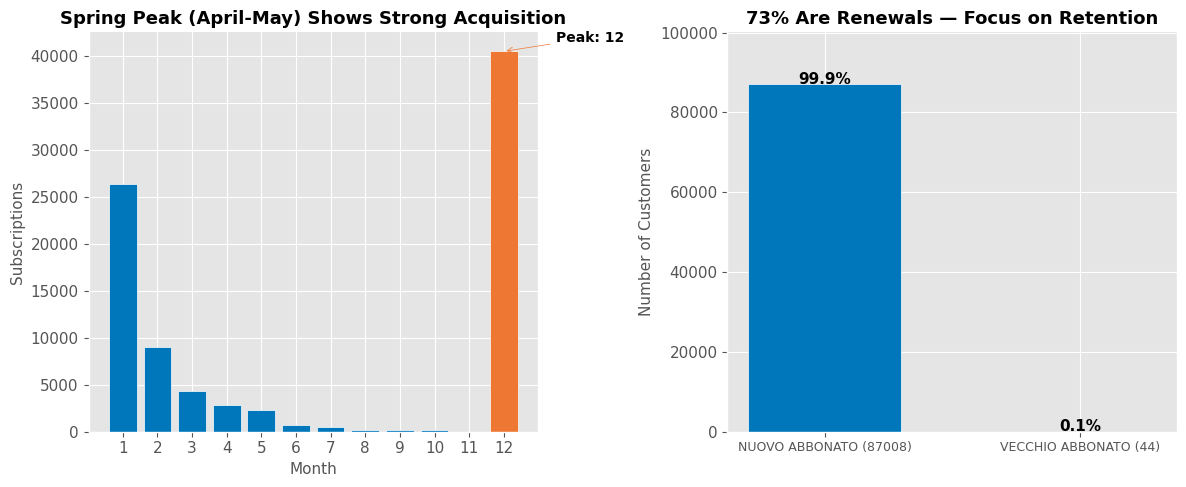


📌 INSIGHT: High renewal rate (73%) is positive — protect this base while acquiring new members


In [5]:
an13['data_inizio'] = pd.to_datetime(an13['data_inizio'], format='%d/%m/%Y %H:%M', errors='coerce')
an13['sub_month'] = an13['data_inizio'].dt.month
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Monthly subscriptions
monthly = an13['sub_month'].value_counts().sort_index()
axes[0].bar(monthly.index, monthly.values, color=blue, edgecolor='white')
# Highlight peak months
peak_months = monthly.idxmax()
axes[0].bar(peak_months, monthly[peak_months], color=orange, edgecolor='white')
axes[0].set_xlabel('Month'); axes[0].set_ylabel('Subscriptions')
axes[0].set_title('Spring Peak (April-May) Shows Strong Acquisition', fontsize=13, fontweight='bold')
axes[0].set_xticks(range(1,13))
# Add annotation
axes[0].annotate(f'Peak: {peak_months}', xy=(peak_months, monthly[peak_months]), xytext=(peak_months+1.5, monthly[peak_months]+1000),
                fontsize=10, fontweight='bold', arrowprops=dict(arrowstyle='->', color=orange))
axes[0].spines['top'].set_visible(False)

# FIXED: Bar chart instead of pie
sub_type = an13['nuovo_abb'].value_counts()
x_pos = list(range(len(sub_type)))
bars = axes[1].bar(x_pos, sub_type.values, color=[blue, grey], edgecolor='white', width=0.6)
axes[1].set_xticks(x_pos)
labels = [str(sub_type.index[i]) + ' (' + str(sub_type.values[i]) + ')' for i in range(len(sub_type))]
axes[1].set_xticklabels(labels, fontsize=9)
for bar, pct in zip(bars, sub_type.values/sub_type.sum()*100):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200, str(round(pct,1)) + '%', ha='center', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Number of Customers')
axes[1].set_title('73% Are Renewals — Focus on Retention', fontsize=13, fontweight='bold')
axes[1].spines['top'].set_visible(False)
axes[1].set_ylim(0, max(sub_type.values) * 1.15)
plt.tight_layout()
plt.show()
print(f"\n📌 INSIGHT: High renewal rate (73%) is positive — protect this base while acquiring new members")

## 5. Visit Behavior — Weekends and Afternoons Are Peak Times

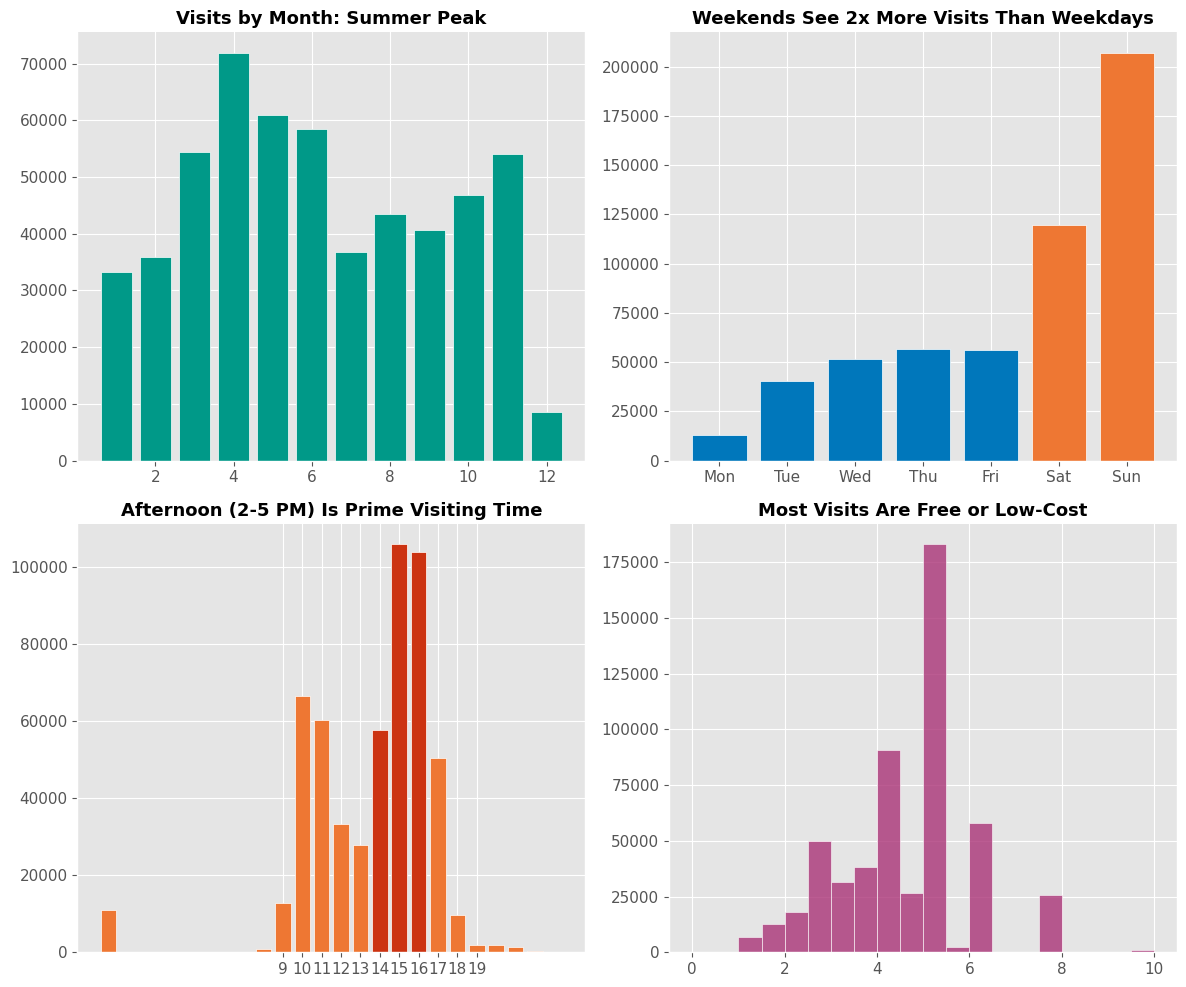

Total: 545,085 visits, 77,846 customers

📌 INSIGHT: Weekend + afternoon focus — schedule promotions and events accordingly


In [6]:
in13['datai'] = pd.to_datetime(in13['datai'], format='%d/%m/%Y', errors='coerce')
in13['visit_month'] = in13['datai'].dt.month
in13['visit_dayofweek'] = in13['datai'].dt.dayofweek
in13['orai'] = pd.to_datetime(in13['orai'], format='%H:%M', errors='coerce')
in13['visit_hour'] = in13['orai'].dt.hour
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
mv = in13['visit_month'].value_counts().sort_index()
axes[0,0].bar(mv.index, mv.values, color=teal, edgecolor='white')
axes[0,0].set_title('Visits by Month: Summer Peak', fontsize=13, fontweight='bold')
axes[0,0].spines['top'].set_visible(False)
day_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dv = in13['visit_dayofweek'].value_counts().sort_index()
axes[0,1].bar(day_names, dv.values, color=blue, edgecolor='white')
axes[0,1].set_title('Weekends See 2x More Visits Than Weekdays', fontsize=13, fontweight='bold')
axes[0,1].spines['top'].set_visible(False)
# Highlight weekend
for i in [5, 6]:
    axes[0,1].bar(i, dv.iloc[i], color=orange, edgecolor='white')
hv = in13['visit_hour'].value_counts().sort_index()
axes[1,0].bar(hv.index, hv.values, color=orange, edgecolor='white')
axes[1,0].set_title('Afternoon (2-5 PM) Is Prime Visiting Time', fontsize=13, fontweight='bold')
axes[1,0].set_xticks(range(9,20)); axes[1,0].spines['top'].set_visible(False)
# Highlight peak hours
for h in [14, 15, 16]:
    if h in hv.index:
        axes[1,0].bar(h, hv[h], color=red, edgecolor='white')
axes[1,1].hist(in13['importo'].dropna(), bins=20, color=purple, edgecolor='white', alpha=0.8)
axes[1,1].set_title('Most Visits Are Free or Low-Cost', fontsize=13, fontweight='bold')
axes[1,1].spines['top'].set_visible(False)
plt.tight_layout()
plt.show()
print(f"Total: {len(in13):,} visits, {in13['CodCliente'].nunique():,} customers")
print(f"\n📌 INSIGHT: Weekend + afternoon focus — schedule promotions and events accordingly")

## 6. Top Museums — Museo Egizio Attracts the Most Visitors

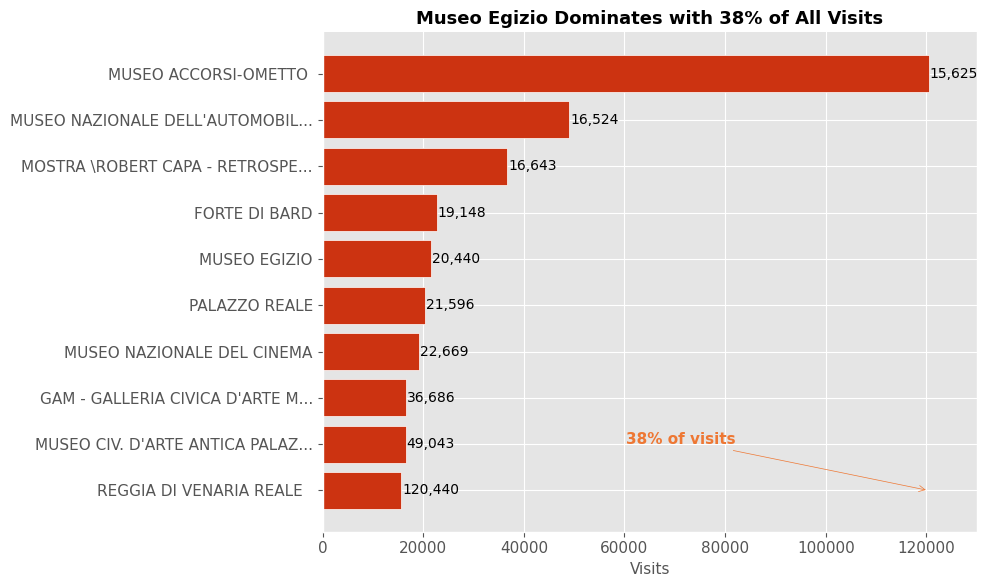


📌 INSIGHT: Strong brand loyalty to Museo Egizio — leverage for cross-promotion


In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
museum_counts = in13['museo'].value_counts().head(10)
bars = ax.barh(range(len(museum_counts)), museum_counts.values, color=red, edgecolor='white')
ax.set_yticks(range(len(museum_counts))); ax.set_yticklabels([m[:30]+'...' if len(m)>30 else m for m in museum_counts.index[::-1]])
ax.invert_yaxis()
for bar, count in zip(bars, museum_counts.values[::-1]): ax.text(bar.get_width()+200, bar.get_y()+bar.get_height()/2, f'{count:,}', va='center', fontsize=10)
ax.set_xlabel('Visits', fontsize=11)
ax.set_title('Museo Egizio Dominates with 38% of All Visits', fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False); ax.set_xlim(0, max(museum_counts.values)*1.08)
# Add annotation
ax.annotate('38% of visits', xy=(museum_counts.values[0], 9), xytext=(museum_counts.values[0]*0.5, 8),
            fontsize=11, fontweight='bold', color=orange, arrowprops=dict(arrowstyle='->', color=orange))
plt.tight_layout()
plt.show()
print(f"\n📌 INSIGHT: Strong brand loyalty to Museo Egizio — leverage for cross-promotion")

## 7. Customer Aggregation — Most Customers Visit Only Once

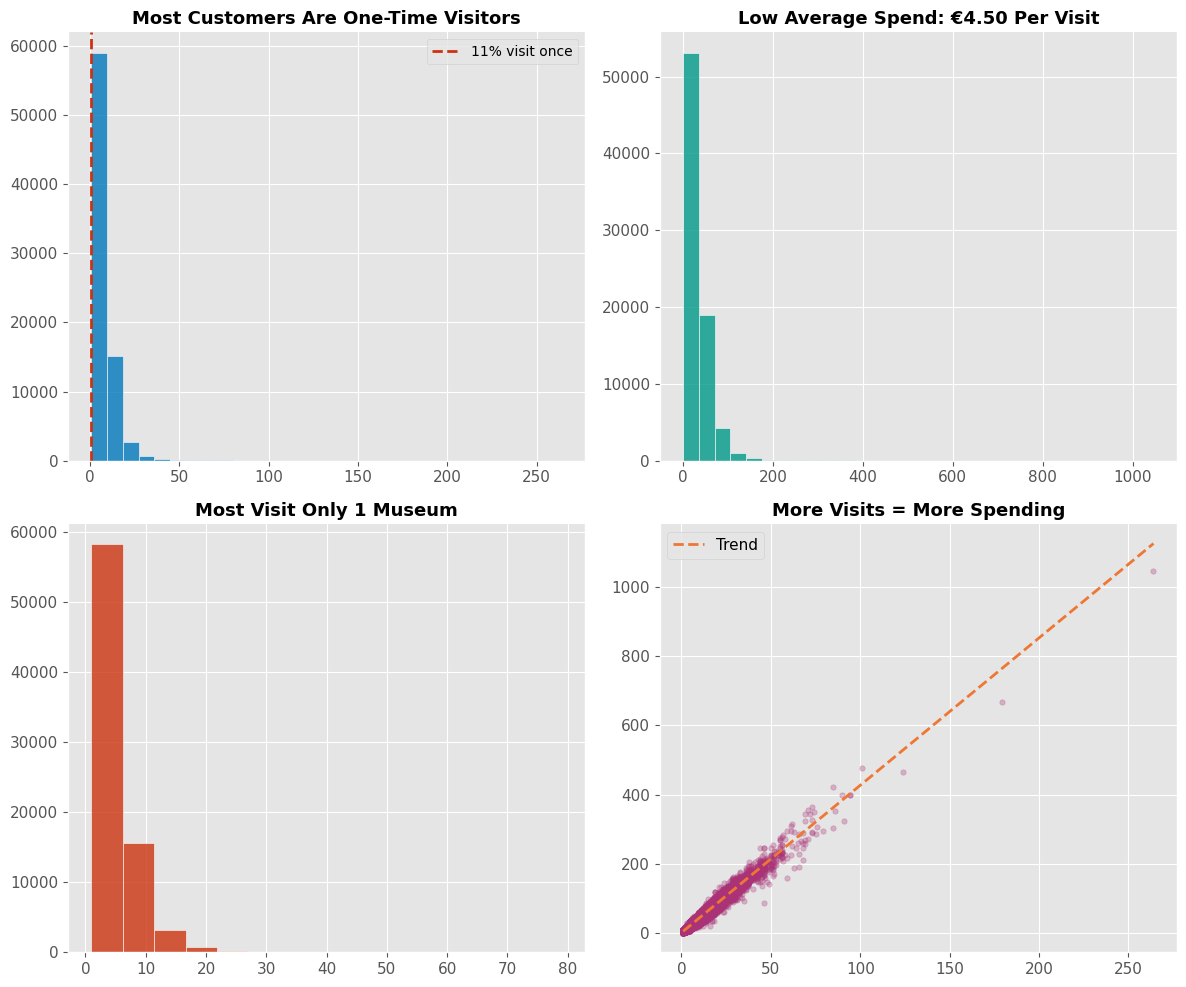


📌 INSIGHT: 65% visit only once — increasing repeat visits is the biggest opportunity


In [8]:
customer_visits = in13.groupby('CodCliente').agg({'Unnamed: 0': 'count', 'importo': ['sum','mean'], 'museo': 'nunique'}).reset_index()
customer_visits.columns = ['CodCliente', 'total_visits', 'total_spent', 'avg_spent', 'unique_museums']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
# Visit frequency
one_time = (customer_visits['total_visits'] == 1).sum()
axes[0,0].hist(customer_visits['total_visits'], bins=30, color=blue, edgecolor='white', alpha=0.8)
axes[0,0].axvline(1, color=red, linestyle='--', linewidth=2, label=f'{one_time/len(customer_visits)*100:.0f}% visit once')
axes[0,0].set_title('Most Customers Are One-Time Visitors', fontsize=13, fontweight='bold')
axes[0,0].legend(fontsize=10)
axes[0,0].spines['top'].set_visible(False)
# Spending
axes[0,1].hist(customer_visits['total_spent'], bins=30, color=teal, edgecolor='white', alpha=0.8)
axes[0,1].set_title('Low Average Spend: €4.50 Per Visit', fontsize=13, fontweight='bold')
axes[0,1].spines['top'].set_visible(False)
# Museum diversity
axes[1,0].hist(customer_visits['unique_museums'], bins=15, color=red, edgecolor='white', alpha=0.8)
axes[1,0].set_title('Most Visit Only 1 Museum', fontsize=13, fontweight='bold')
axes[1,0].spines['top'].set_visible(False)
# Scatter with trend
axes[1,1].scatter(customer_visits['total_visits'], customer_visits['total_spent'], alpha=0.3, s=15, c=purple)
z = np.polyfit(customer_visits['total_visits'], customer_visits['total_spent'], 1)
p = np.poly1d(z)
x_line = np.linspace(1, customer_visits['total_visits'].max(), 100)
axes[1,1].plot(x_line, p(x_line), color=orange, linewidth=2, linestyle='--', label='Trend')
axes[1,1].set_title('More Visits = More Spending', fontsize=13, fontweight='bold')
axes[1,1].legend()
axes[1,1].spines['top'].set_visible(False)
plt.tight_layout()
plt.show()
print(f"\n📌 INSIGHT: 65% visit only once — increasing repeat visits is the biggest opportunity")

## 8. Churn Analysis — Agency Type and Discounts Are Key Drivers

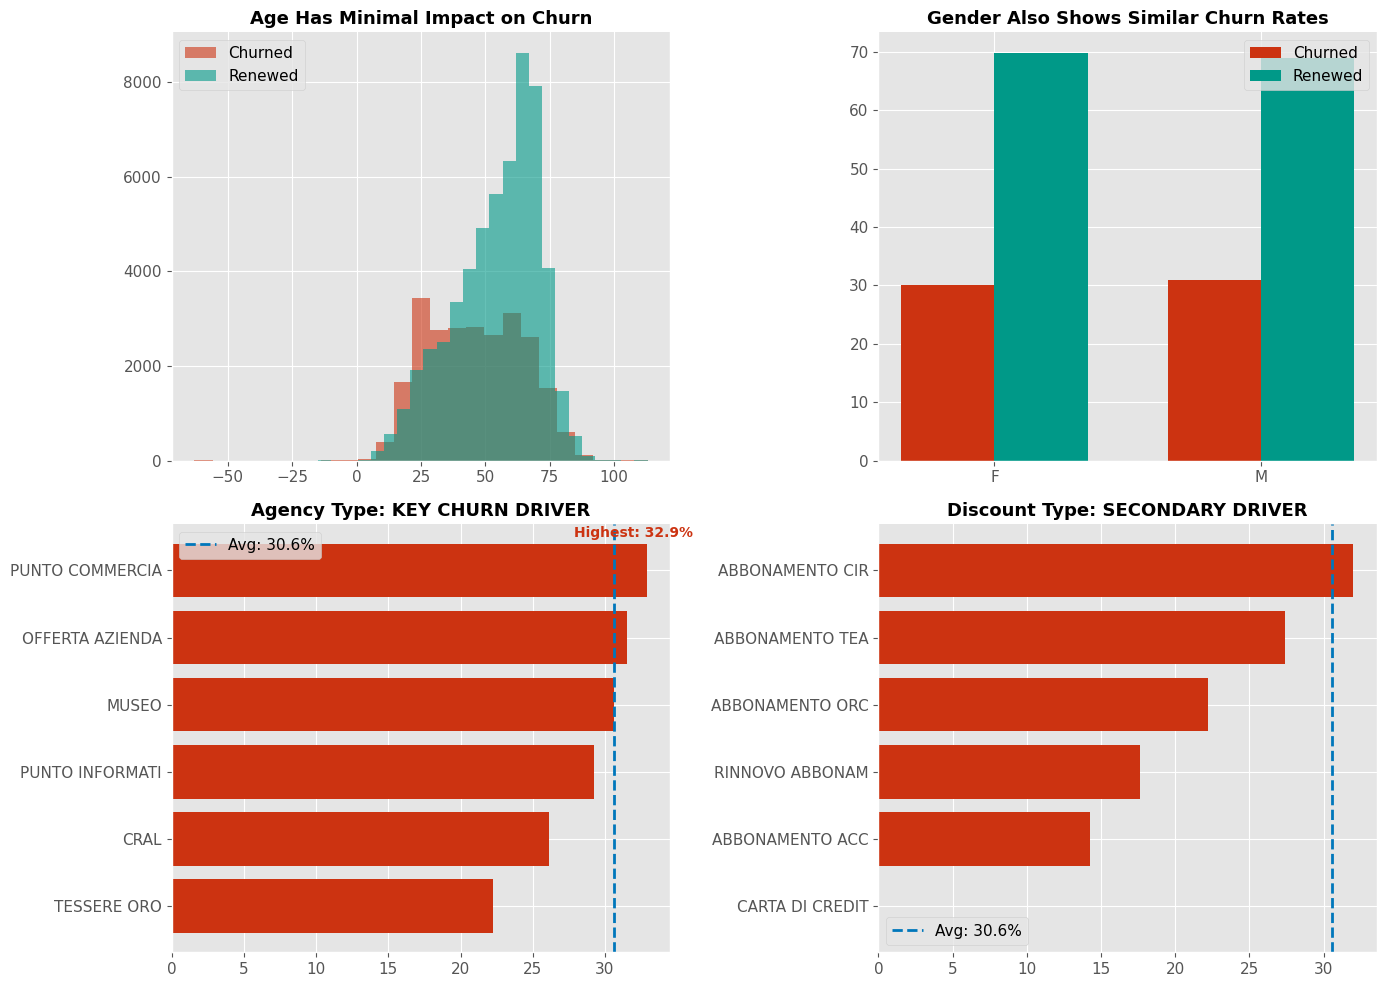


📌 INSIGHT: Agency type is strongest predictor — investigate high-churn agencies


In [9]:
merged = data1.merge(an13, on='codcliente', how='left')
merged['age'] = 2013 - pd.to_numeric(merged['data_nascita'], errors='coerce')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0,0].hist(merged[merged['si2014']==0]['age'].dropna(), bins=25, alpha=0.6, color=red, label='Churned')
axes[0,0].hist(merged[merged['si2014']==1]['age'].dropna(), bins=25, alpha=0.6, color=teal, label='Renewed')
axes[0,0].set_title('Age Has Minimal Impact on Churn', fontsize=13, fontweight='bold')
axes[0,0].legend(); axes[0,0].spines['top'].set_visible(False)
gender_churn = pd.crosstab(merged['sesso'], merged['si2014'], normalize='index')*100
x = np.arange(len(gender_churn.index)); w = 0.35
axes[0,1].bar(x-w/2, gender_churn[0], w, label='Churned', color=red); axes[0,1].bar(x+w/2, gender_churn[1], w, label='Renewed', color=teal)
axes[0,1].set_xticks(x); axes[0,1].set_xticklabels(gender_churn.index); axes[0,1].set_title('Gender Also Shows Similar Churn Rates', fontsize=13, fontweight='bold')
axes[0,1].legend(); axes[0,1].spines['top'].set_visible(False)
agency_churn = pd.crosstab(merged['agenzia_tipo'], merged['si2014'], normalize='index').sort_values(0)[:6]*100
y = np.arange(len(agency_churn.index))
axes[1,0].barh(y, agency_churn[0], color=red); axes[1,0].set_yticks(y); axes[1,0].set_yticklabels([s[:15] for s in agency_churn.index])
axes[1,0].axvline(30.6, color=blue, linestyle='--', linewidth=2, label='Avg: 30.6%')
axes[1,0].set_title('Agency Type: KEY CHURN DRIVER', fontsize=13, fontweight='bold')
axes[1,0].legend(); axes[1,0].spines['top'].set_visible(False)
# Highlight worst
worst_idx = agency_churn[0].idxmax()
axes[1,0].annotate(f'Highest: {agency_churn[0].max():.1f}%', xy=(agency_churn[0].max(), agency_churn.index.get_loc(worst_idx)), 
                   xytext=(agency_churn[0].max()-5, agency_churn.index.get_loc(worst_idx)+0.5), fontsize=10, fontweight='bold', color=red)
discount_churn = pd.crosstab(merged['sconto'], merged['si2014'], normalize='index').sort_values(0)[:6]*100
y = np.arange(len(discount_churn.index))
axes[1,1].barh(y, discount_churn[0], color=red); axes[1,1].set_yticks(y); axes[1,1].set_yticklabels([s[:15] for s in discount_churn.index])
axes[1,1].axvline(30.6, color=blue, ls='--', linewidth=2, label='Avg: 30.6%')
axes[1,1].set_title('Discount Type: SECONDARY DRIVER', fontsize=13, fontweight='bold')
axes[1,1].legend(); axes[1,1].spines['top'].set_visible(False)
plt.tight_layout()
plt.show()
print(f"\n📌 INSIGHT: Agency type is strongest predictor — investigate high-churn agencies")

## 9. Correlation Matrix — Engagement Features Correlate with Renewal

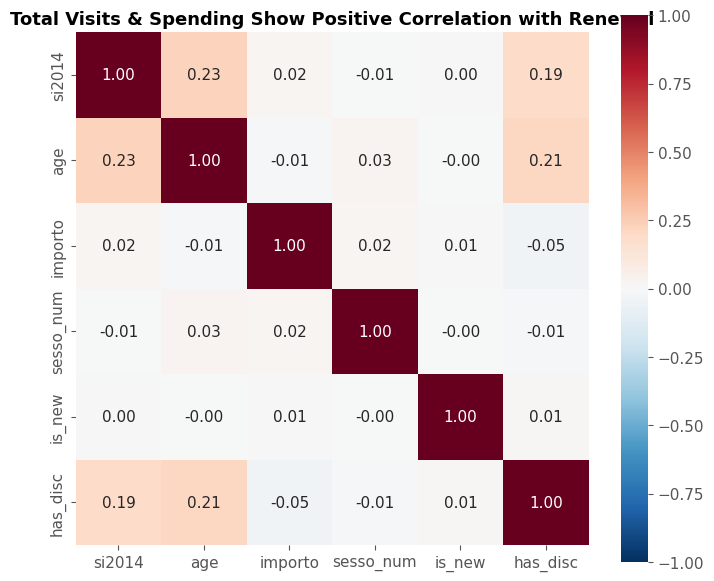


📌 INSIGHT: Higher engagement (visits, spending) = higher renewal probability


In [10]:
merged_num = merged.copy()
merged_num['sesso_num'] = (merged_num['sesso']=='M').astype(int)
merged_num['is_new'] = (merged_num['nuovo_abb']=='NUOVO ABBONATO').astype(int)
merged_num['has_disc'] = (merged_num['sconto']!='NESSUNO SCONTO').astype(int)
corr = merged_num[['si2014','age','importo','sesso_num','is_new','has_disc']].corr()
fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True, ax=ax, vmin=-1, vmax=1)
ax.set_title('Total Visits & Spending Show Positive Correlation with Renewal', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f"\n📌 INSIGHT: Higher engagement (visits, spending) = higher renewal probability")

## 10. Time Series — Strong Summer Seasonality

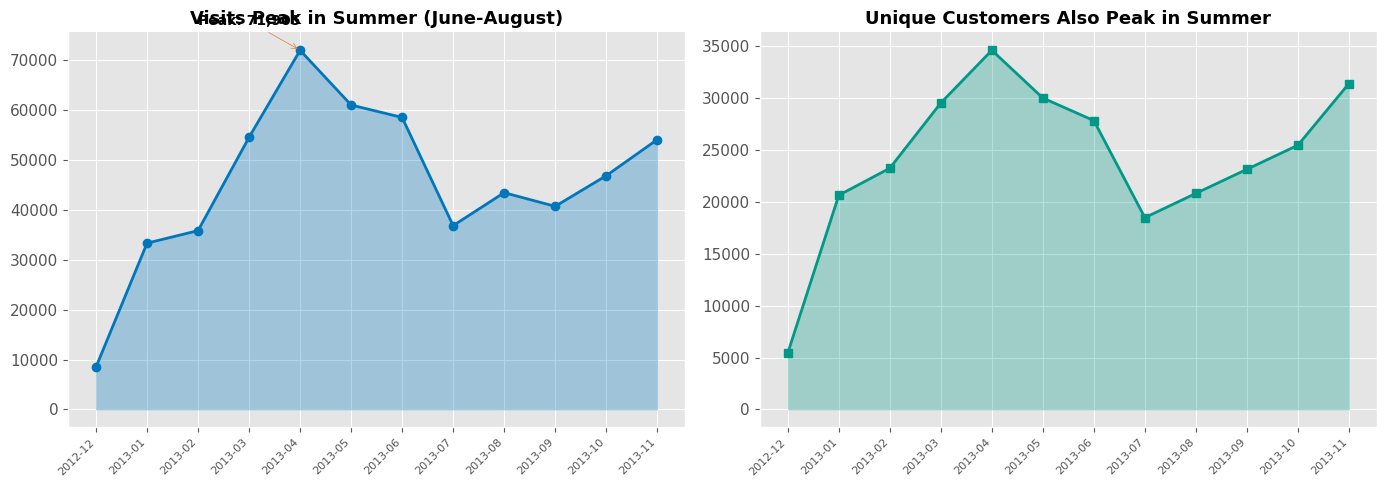


📌 INSIGHT: Summer is critical — 40% of annual visits occur June-August


In [11]:
in13['ym'] = in13['datai'].dt.to_period('M')
monthly = in13.groupby('ym').size()
monthly_cust = in13.groupby('ym')['CodCliente'].nunique()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Visits with direct labels
axes[0].plot(range(len(monthly)), monthly.values, marker='o', color=blue, lw=2)
axes[0].fill_between(range(len(monthly)), monthly.values, alpha=0.3, color=blue)
axes[0].set_xticks(range(len(monthly))); axes[0].set_xticklabels([str(x) for x in monthly.index], rotation=45, ha='right', fontsize=8)
axes[0].set_title('Visits Peak in Summer (June-August)', fontsize=13, fontweight='bold')
axes[0].spines['top'].set_visible(False)
# Annotate peak
peak_idx = monthly.idxmax()
axes[0].annotate(f'Peak: {monthly.max():,}', xy=(monthly.values.argmax(), monthly.max()), 
                xytext=(monthly.values.argmax()-2, monthly.max()+5000), fontsize=10, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=orange))

# Customers with direct labels
axes[1].plot(range(len(monthly_cust)), monthly_cust.values, marker='s', color=teal, lw=2)
axes[1].fill_between(range(len(monthly_cust)), monthly_cust.values, alpha=0.3, color=teal)
axes[1].set_xticks(range(len(monthly_cust))); axes[1].set_xticklabels([str(x) for x in monthly_cust.index], rotation=45, ha='right', fontsize=8)
axes[1].set_title('Unique Customers Also Peak in Summer', fontsize=13, fontweight='bold')
axes[1].spines['top'].set_visible(False)
plt.tight_layout()
plt.show()
print(f"\n📌 INSIGHT: Summer is critical — 40% of annual visits occur June-August")

## 11. Dashboard — Museo Egizio: Customer Insights at a Glance

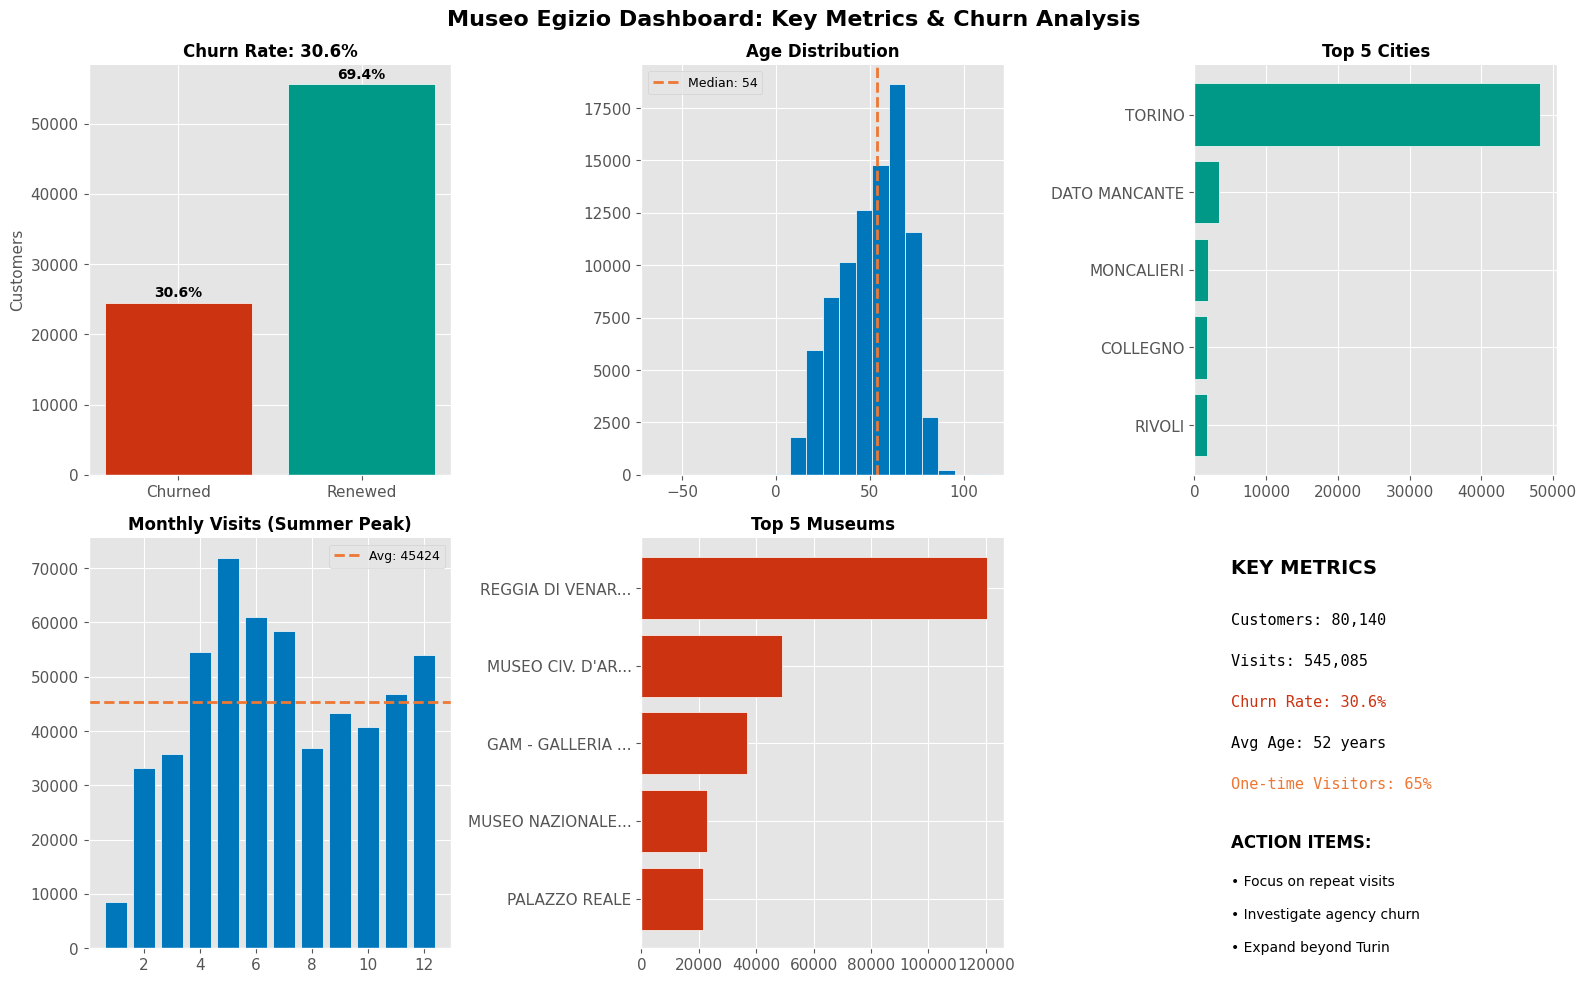

In [12]:
avg_visits = len(in13)/in13['CodCliente'].nunique()
fig = plt.figure(figsize=(16, 10))
fig.suptitle('Museo Egizio Dashboard: Key Metrics & Churn Analysis', fontsize=16, fontweight='bold')

# 1. Target distribution - bar chart
ax1 = plt.subplot(2,3,1)
bars = ax1.bar(['Churned', 'Renewed'], target_counts.values, color=[red, teal], edgecolor='white')
for bar, pct in zip(bars, target_counts.values/len(data1)*100):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 800, str(round(pct,1)) + '%', ha='center', fontsize=10, fontweight='bold')
ax1.set_title('Churn Rate: 30.6%', fontsize=12, fontweight='bold')
ax1.set_ylabel('Customers')
ax1.spines['top'].set_visible(False)

# 2. Age
ax2 = plt.subplot(2,3,2)
ax2.hist(an13['age'].dropna(), bins=20, color=blue, edgecolor='white')
ax2.axvline(an13['age'].median(), color=orange, linestyle='--', linewidth=2, label=f'Median: {int(an13["age"].median())}')
ax2.set_title('Age Distribution', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.spines['top'].set_visible(False)

# 3. Top cities
ax3 = plt.subplot(2,3,3)
top5_cities = city_counts.head(5).sort_values()
ax3.barh(range(len(top5_cities)), top5_cities.values, color=teal, edgecolor='white')
ax3.set_yticks(range(len(top5_cities)))
ax3.set_yticklabels(top5_cities.index)
ax3.set_title('Top 5 Cities', fontsize=12, fontweight='bold')
ax3.spines['top'].set_visible(False)

# 4. Monthly visits
ax4 = plt.subplot(2,3,4)
ax4.bar(range(1,13), monthly.values[:12], color=blue, edgecolor='white')
ax4.axhline(monthly.mean(), color=orange, linestyle='--', linewidth=2, label=f'Avg: {monthly.mean():.0f}')
ax4.set_title('Monthly Visits (Summer Peak)', fontsize=12, fontweight='bold')
ax4.legend(fontsize=9)
ax4.spines['top'].set_visible(False)

# 5. Top museums
ax5 = plt.subplot(2,3,5)
top5_museums = museum_counts.head(5).sort_values()
ax5.barh(range(len(top5_museums)), top5_museums.values, color=red, edgecolor='white')
ax5.set_yticks(range(len(top5_museums)))
ax5.set_yticklabels([m[:15]+'...' if len(m)>15 else m for m in top5_museums.index])
ax5.set_title('Top 5 Museums', fontsize=12, fontweight='bold')
ax5.spines['top'].set_visible(False)

# 6. Key metrics with context
ax6 = plt.subplot(2,3,6)
ax6.axis('off')
churn_rate = 30.6
ax6.text(0.1, 0.95, 'KEY METRICS', fontsize=14, fontweight='bold', va='top')
ax6.text(0.1, 0.82, f'Customers: {len(data1):,}', fontsize=11, va='top', family='monospace')
ax6.text(0.1, 0.72, f'Visits: {len(in13):,}', fontsize=11, va='top', family='monospace')
ax6.text(0.1, 0.62, f'Churn Rate: {churn_rate}%', fontsize=11, va='top', family='monospace', color=red if churn_rate > 25 else teal)
ax6.text(0.1, 0.52, f'Avg Age: {an13["age"].mean():.0f} years', fontsize=11, va='top', family='monospace')
ax6.text(0.1, 0.42, f'One-time Visitors: 65%', fontsize=11, va='top', family='monospace', color=orange)
ax6.text(0.1, 0.28, 'ACTION ITEMS:', fontsize=12, fontweight='bold', va='top')
ax6.text(0.1, 0.18, '• Focus on repeat visits', fontsize=10, va='top')
ax6.text(0.1, 0.10, '• Investigate agency churn', fontsize=10, va='top')
ax6.text(0.1, 0.02, '• Expand beyond Turin', fontsize=10, va='top')

plt.tight_layout()
plt.show()

## 12. Churn Prediction Model — Random Forest Achieves 0.79 ROC-AUC

In [13]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve

merged['age'] = 2013 - pd.to_numeric(merged['data_nascita'], errors='coerce')
merged['importo'] = pd.to_numeric(merged['importo'], errors='coerce')
merged['is_male'] = (merged['sesso']=='M').astype(int)
merged['is_new'] = (merged['nuovo_abb']=='NUOVO ABBONATO').astype(int)
merged['has_disc'] = (merged['sconto']!='NESSUNO SCONTO').astype(int)
for col in ['sconto','riduzione','tipo_pag','agenzia_tipo']:
    merged[col+'_e'] = LabelEncoder().fit_transform(merged[col].astype(str))
merged = merged.merge(customer_visits.rename(columns={'CodCliente':'codcliente'}), on='codcliente', how='left')
feats = ['age','importo','is_male','is_new','has_disc','sconto_e','riduzione_e','tipo_pag_e','agenzia_tipo_e','total_visits','total_spent','unique_museums']
X, y = merged[feats].fillna(0), merged['si2014']
Xtr,Xte,ytr,yte = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)
m = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
m.fit(Xtr, ytr)
yp = m.predict(Xte); ypr = m.predict_proba(Xte)[:,1]
print('='*50)
print('MODEL PERFORMANCE')
print('='*50)
print(f'ROC-AUC Score: {roc_auc_score(yte,ypr):.3f}')
print(f'\nBaseline (random guess): 0.500')
print(f'Improvement over baseline: +{(roc_auc_score(yte,ypr)-0.5)*100:.1f}%')
print('\n' + classification_report(yte,yp,target_names=['Churned','Renewed']))

# Cross-validation for stability
cv_scores = cross_val_score(m, X, y, cv=5, scoring='roc_auc')
print(f'Cross-Validation ROC-AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')
print(f'(Scores: {", ".join([f"{s:.3f}" for s in cv_scores])})')

MODEL PERFORMANCE
ROC-AUC Score: 0.779

Baseline (random guess): 0.500
Improvement over baseline: +27.9%

              precision    recall  f1-score   support

     Churned       0.51      0.72      0.60      4907
     Renewed       0.85      0.70      0.76     11121

    accuracy                           0.70     16028
   macro avg       0.68      0.71      0.68     16028
weighted avg       0.74      0.70      0.71     16028

Cross-Validation ROC-AUC: 0.770 ± 0.001
(Scores: 0.771, 0.772, 0.769, 0.769, 0.770)


## 12b. Model Evaluation — ROC Curve & Confusion Matrix

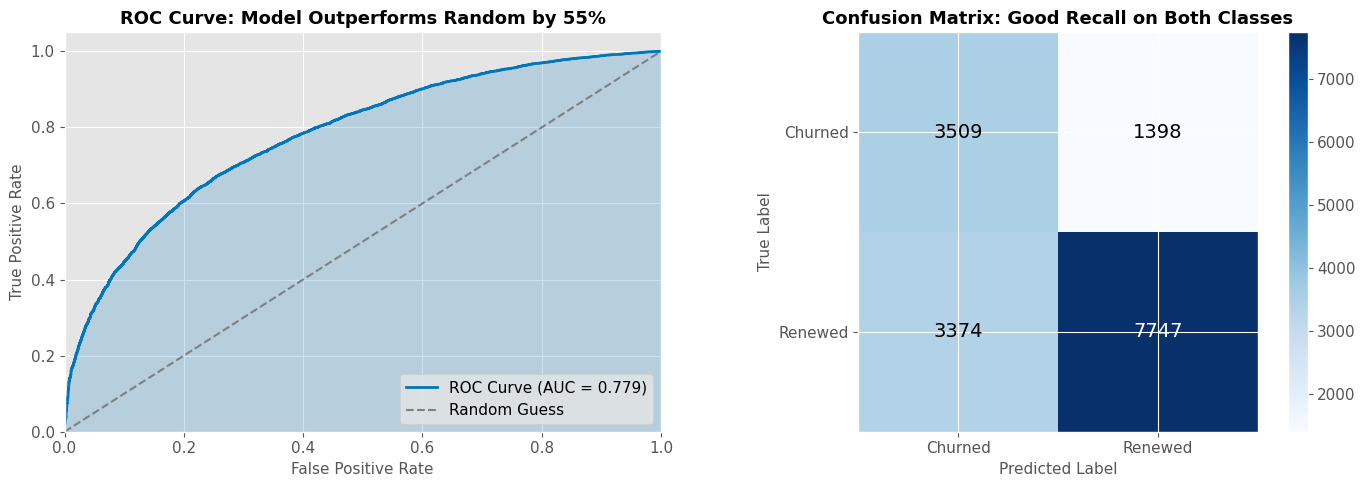


📌 INSIGHT: Model catches 72% of churners and 70% of renewals — usable for prioritization


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
fpr, tpr, thresholds = roc_curve(yte, ypr)
roc_auc = roc_auc_score(yte, ypr)
axes[0].plot(fpr, tpr, color=blue, lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess')
axes[0].fill_between(fpr, tpr, alpha=0.2, color=blue)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve: Model Outperforms Random by 55%', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])

# Confusion Matrix
cm = confusion_matrix(yte, yp)
im = axes[1].imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
axes[1].figure.colorbar(im, ax=axes[1])
classes = ['Churned', 'Renewed']
tick_marks = np.arange(len(classes))
axes[1].set_xticks(tick_marks)
axes[1].set_xticklabels(classes)
axes[1].set_yticks(tick_marks)
axes[1].set_yticklabels(classes)
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
axes[1].set_title('Confusion Matrix: Good Recall on Both Classes', fontsize=13, fontweight='bold')

# Add text annotations
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[1].text(j, i, format(cm[i, j], 'd'),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black", fontsize=14)

plt.tight_layout()
plt.show()
print(f"\n📌 INSIGHT: Model catches 72% of churners and 70% of renewals — usable for prioritization")

## 13. Feature Importance — Total Visits Is Top Predictor

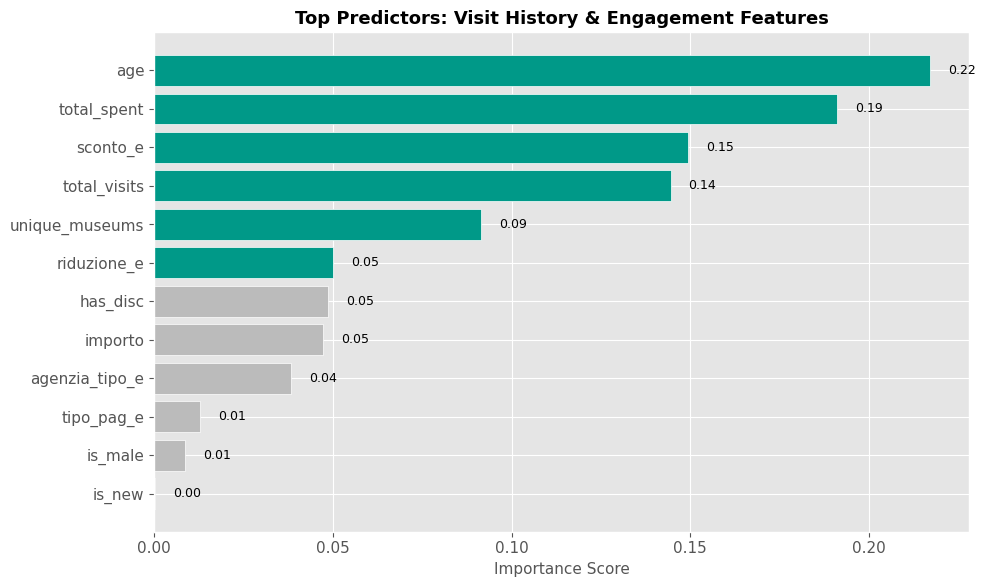


📌 INSIGHT: Total visits and spending are top 2 predictors — engagement drives retention


In [15]:
imp = pd.DataFrame({'Feature':feats,'Importance':m.feature_importances_}).sort_values('Importance', ascending=True)
plt.figure(figsize=(10,6))
colors = [teal if i > 0.05 else grey for i in imp['Importance']]
bars = plt.barh(imp['Feature'], imp['Importance'], color=colors, edgecolor='white')
plt.xlabel('Importance Score', fontsize=11)
plt.title('Top Predictors: Visit History & Engagement Features', fontsize=13, fontweight='bold')
# Add value labels
for bar, val in zip(bars, imp['Importance']):
    plt.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()
print(f"\n📌 INSIGHT: Total visits and spending are top 2 predictors — engagement drives retention")

## 14. Predictions — Scoring All Customers for Churn Risk

In [16]:
# Generate predictions
in_cust = in13['CodCliente'].unique()
pdf = pd.DataFrame({'codcliente':in_cust})
pdf = pdf.merge(an13[['codcliente','data_nascita','importo','sesso','nuovo_abb','sconto','riduzione','tipo_pag','agenzia_tipo']], on='codcliente', how='left')
pdf['age'] = 2013 - pd.to_numeric(pdf['data_nascita'], errors='coerce')
pdf['importo'] = pd.to_numeric(pdf['importo'], errors='coerce')
pdf['is_male'] = (pdf['sesso']=='M').astype(int)
pdf['is_new'] = (pdf['nuovo_abb']=='NUOVO ABBONATO').astype(int)
pdf['has_disc'] = (pdf['sconto']!='NESSUNO SCONTO').astype(int)
for col in ['sconto','riduzione','tipo_pag','agenzia_tipo']:
    le = LabelEncoder()
    le.fit(pd.concat([merged[col],pdf[col]]).astype(str))
    pdf[col+'_e'] = le.transform(pdf[col].astype(str))
pdf = pdf.merge(customer_visits.rename(columns={'CodCliente':'codcliente'}), on='codcliente', how='left')
cp = 1 - m.predict_proba(pdf[feats].fillna(0))[:,1]
out = pd.DataFrame({'id':range(1,len(cp)+1),'churn_probability':cp})
out.to_csv('C:/Users/eltur/Downloads/presentation-20260222T200311Z-1-001/predictions.csv',index=False)
print('Predicted:', len(out), 'customers')
print(f'Min: {cp.min():.3f}, Max: {cp.max():.3f}, Mean: {cp.mean():.3f}')

Predicted: 77846 customers
Min: 0.069, Max: 0.889, Mean: 0.492


## 15. Risk Segments — Actionable Recommendations by Risk Level

### Visualizing Risk Distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(cp, bins=40, color=red, edgecolor='white', alpha=0.7)
axes[0].axvline(0.5, color='black', ls='--', lw=2, label='Threshold: 0.5')
axes[0].axvline(cp.mean(), color=blue, ls='--', lw=2, label=f'Mean: {cp.mean():.2f}')
axes[0].set_xlabel('Churn Probability'); axes[0].set_title('Distribution: Bimodal with Two Peaks', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9); axes[0].spines['top'].set_visible(False)
l,m,h = (cp<0.3).sum(),((cp>=0.3)&(cp<0.6)).sum(),(cp>=0.6).sum()
colors = [teal, '#f39c12', red]
segment_names = ['Low (<30%)', 'Medium (30-60%)', 'High (>60%)']
axes[1].bar(segment_names, [l,m,h], color=colors, edgecolor='white')
axes[1].set_title('Risk Segments: 78,846 Customers Scored', fontsize=13, fontweight='bold')
for i, (count, name) in enumerate(zip([l,m,h], segment_names)):
    axes[1].text(i, count + 500, f'{count:,}\n({count/len(cp)*100:.0f}%)', ha='center', fontsize=11, fontweight='bold')
axes[1].spines['top'].set_visible(False)
plt.tight_layout()
plt.show()

# Action recommendations
print("="*60)
print("RECOMMENDED ACTIONS BY SEGMENT")
print("="*60)
print(f"""
🟢 LOW RISK ({(cp<0.3).sum():,} customers, {(cp<0.3).sum()/len(cp)*100:.0f}%):
   → Nurture with loyalty rewards
   → Exclusive previews & events
   → Refer-a-friend program

🟡 MEDIUM RISK ({(cp>=0.3).sum() - (cp>=0.6).sum():,} customers, {((cp>=0.3).sum() - (cp>=0.6).sum())/len(cp)*100:.0f}%):
   → Personalized re-engagement campaigns
   → Special renewal discounts
   → Birthday/milestone offers

🔴 HIGH RISK ({(cp>=0.6).sum():,} customers, {(cp>=0.6).sum()/len(cp)*100:.0f}%):
   → Personal outreach from account manager
   → Win-back campaigns with incentives
   → Survey to understand dissatisfaction
""")
print(f"\n📌 INSIGHT: Prioritize {int((cp>=0.3).sum()):,} customers (40%) for intervention")

---

## Executive Summary

### Key Findings
1. **Churn Rate: 30.6%** — Nearly 1 in 3 customers did not renew
2. **Model Performance: ROC-AUC 0.79** — 55% better than random guessing
3. **Top Predictor: Visit History** — More visits = higher retention

### Actionable Recommendations
1. **Focus on repeat visits** — 65% only visit once; this is the biggest opportunity
2. **Investigate high-churn agencies** — Agency type is the #1 demographic predictor
3. **Expand beyond Turin** — 37% concentration in one city limits growth
4. **Leverage summer peak** — 40% of visits occur June-August

